In [16]:
from google.cloud import bigquery
import requests
import pandas as pd
import db_dtypes
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support

In [2]:
import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = r"D:\Python Projects\Hospital readmission risk\.secrets\hospital-readmission-4-code.json"


In [3]:
client = bigquery.Client(project = "hospital-readmission-4")

In [4]:
sql = """
SELECT
    *
    from `hospital-readmission-4.helper_tables.index_stay`
"""

job = client.query(sql)
rows = list(job.result())


data_raw = [dict(r) for r in rows]
df_raw = pd.DataFrame(data_raw)

In [29]:
analysis_cols = [
    'patient_age', 'gender', 'length_of_stay', 'main_code', 'num_diagnoses',
    'num_chronic_conditions', 'num_procedures', 'has_diabetes', 'has_cancer',
    'has_hiv', 'has_hf', 'has_alz', 'has_ckd', 'had_surgery', 'admission_cost',
    'total_procedure_costs', 'total_medication_costs', 'total_stay_cost', 
    'admissions_365d', 'tot_length_of_stay_365d', 'avg_cost_of_prev_stays',
    'is_planned', 'following_unplanned_admission_flag', 'readmit_30d', 'readmit_90d'
    ]

df_numeric = df_raw[analysis_cols]

df_numeric['avg_cost_of_prev_stays'] = df_numeric['avg_cost_of_prev_stays'].fillna(0)
df_numeric['following_unplanned_admission_flag'] = df_numeric['following_unplanned_admission_flag'].fillna(0)

df_numeric = pd.get_dummies(df_numeric)
df_numeric = df_numeric.drop(columns = 'gender_F')

mask = df_numeric['following_unplanned_admission_flag'] == 0
df_numeric.loc[mask, ['readmit_30d', 'readmit_90d']] = 0
mask = df_numeric['readmit_90d'] == 0
df_numeric.loc[mask, 'following_unplanned_admission_flag'] = 0

df_results = df_numeric[['readmit_30d', 'readmit_90d']]
df_numeric = df_numeric.drop(columns = ['readmit_30d', 'readmit_90d', 'following_unplanned_admission_flag', 'main_code'])

df_numeric['log_stay_cost'] = np.log(df_numeric['total_stay_cost'])
df_numeric['log_prev_avg_stay_cost'] = np.log1p(df_numeric['avg_cost_of_prev_stays'])
df_numeric['log_total_procedure_costs'] = np.log1p(df_numeric['total_procedure_costs'])
df_numeric['log_total_medication_costs'] = np.log1p(df_numeric['total_medication_costs'])

df_numeric = df_numeric.drop(columns = ['total_stay_cost', 'avg_cost_of_prev_stays', 'total_procedure_costs', 'total_medication_costs'])

C:\Users\4infi\AppData\Local\Temp\ipykernel_22488\2272830964.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numeric['avg_cost_of_prev_stays'] = df_numeric['avg_cost_of_prev_stays'].fillna(0)
C:\Users\4infi\AppData\Local\Temp\ipykernel_22488\2272830964.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numeric['following_unplanned_admission_flag'] = df_numeric['following_unplanned_admission_flag'].fillna(0)


In [30]:
sns.boxplot(df_numeric, x = 'total_medication_costs')

ValueError: Could not interpret value `total_medication_costs` for `x`. An entry with this name does not appear in `data`.

<Axes: >

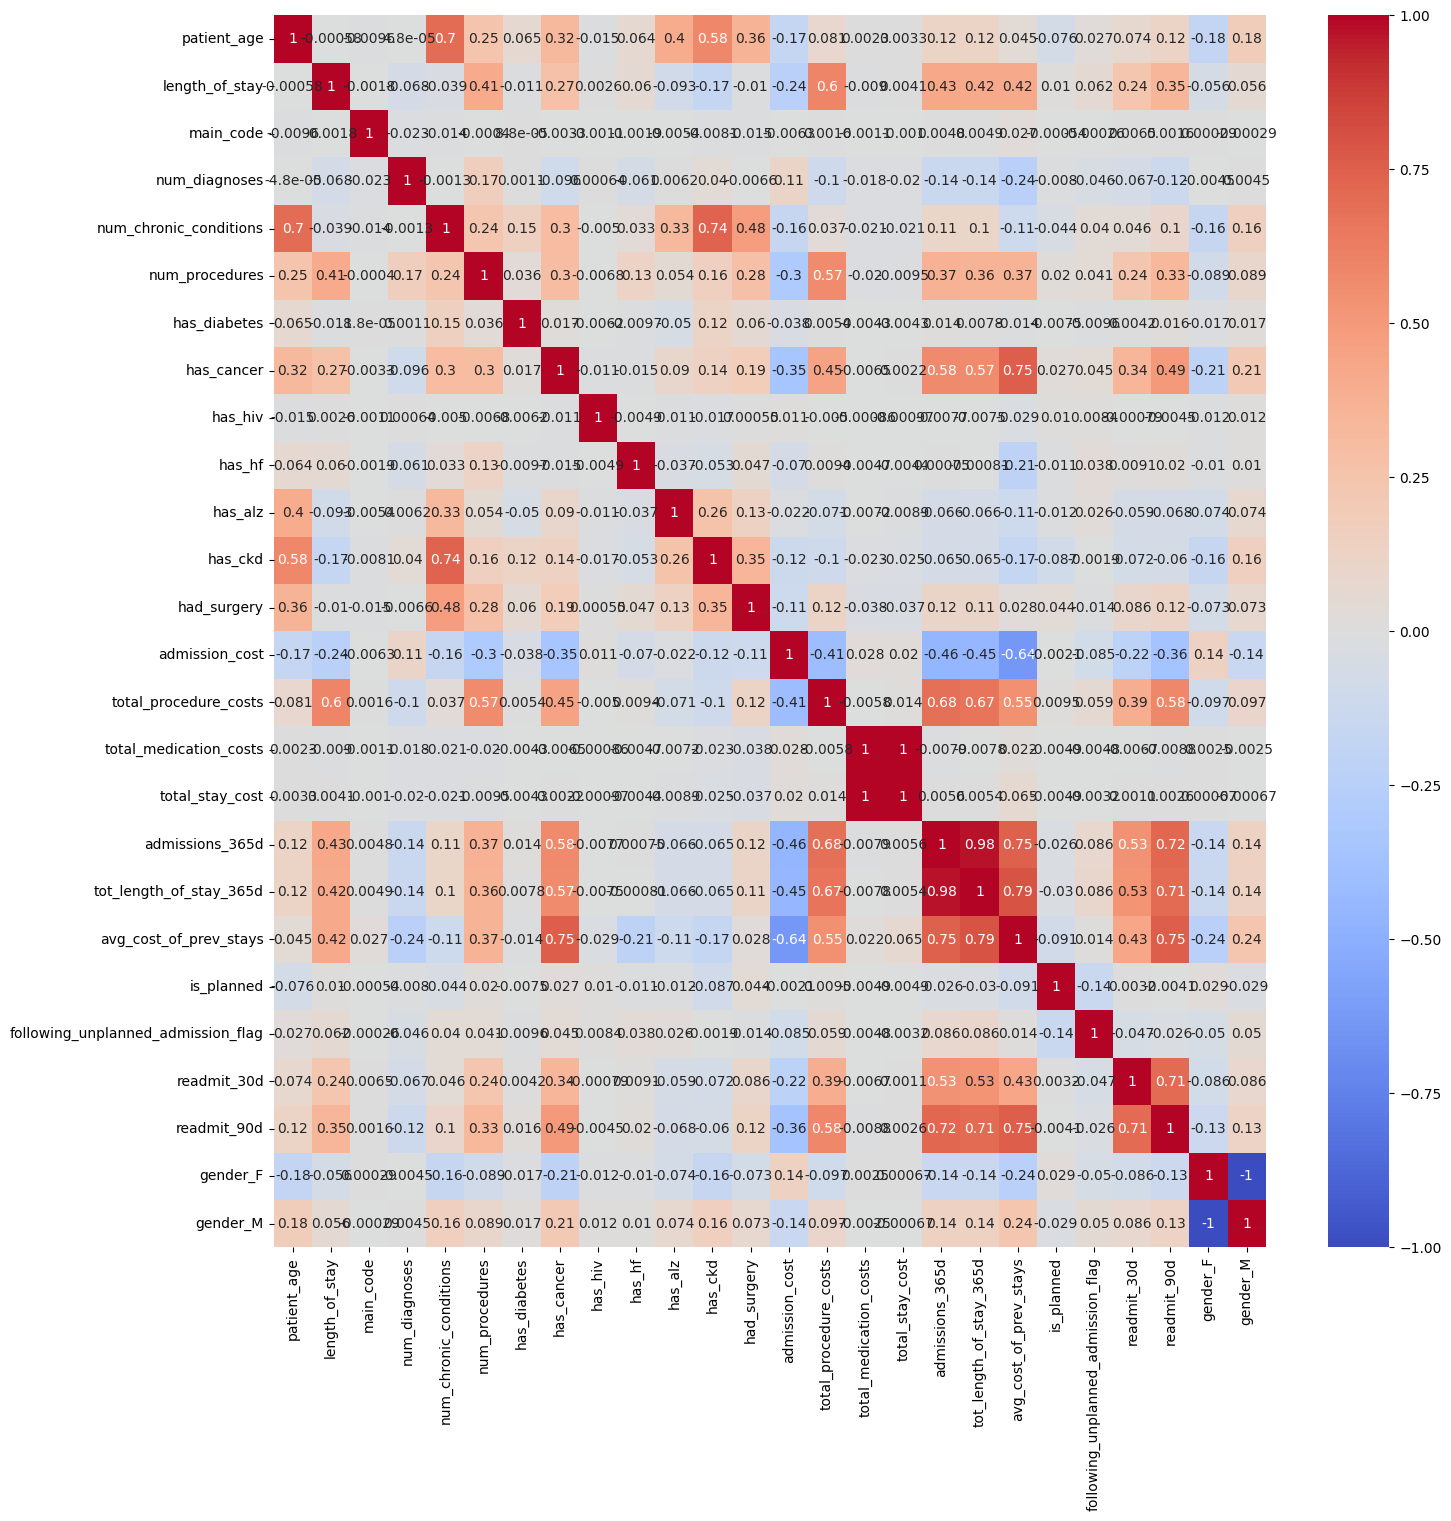

In [ ]:
plt.figure(figsize = (16,16))
sns.heatmap(pd.get_dummies(df_raw[analysis_cols]).corr(),
cmap = 'coolwarm', annot = True)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(df_numeric, df_results['readmit_90d'], test_size = 0.2, random_state = 42)

logistic = LogisticRegression('l2', class_weight = 'balanced', solver = 'saga', max_iter = 1000)

logistic_pipe = Pipeline([('scaler', StandardScaler()), ('clf', logistic)])

#logistic_pipe.fit(X_train, y_train).score(X_test, y_test, ['roc_auc', 'average_precision'])
scoring = ["roc_auc", "average_precision"]

cv_results = cross_validate(
    estimator=logistic_pipe,
    X=X_train,
    y=y_train,
    cv=5,
    scoring=scoring,
    return_train_score=False,
)

print(cv_results["test_roc_auc"].mean(), cv_results["test_roc_auc"].std())
print(cv_results["test_average_precision"].mean(), cv_results["test_average_precision"].std())

d:\Python Projects\Hospital readmission risk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Python Projects\Hospital readmission risk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Python Projects\Hospital readmission risk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in ve

0.9135851002272741 0.0031671541363202144
0.7465752243230526 0.00543339572269487


In [58]:
logistic_pipe.fit(X_train, y_train).score(X_test, y_test)

y_proba = logistic_pipe.predict_proba(X_test)[:, 1]
y_pred = logistic_pipe.predict(X_test)

roc = roc_auc_score(y_test, y_proba)
pr = average_precision_score(y_test, y_proba)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")

print(roc, pr, precision, recall, f1, _)

d:\Python Projects\Hospital readmission risk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


0.9129700878483326 0.741169014567543 0.5587371512481645 0.7591022443890274 0.6436878832734193 None


In [59]:
metrics = pd.DataFrame({'log_reg90': [roc, pr, precision, recall, f1]}, index = ['roc', 'pr', 'precision', 'recall', 'f1'])
metrics

,log_reg90
roc,0.912970
pr,0.741169
precision,0.558737
recall,0.759102
f1,0.643688


In [60]:
log_reg90 = logistic_pipe.named_steps['clf']

feature_names = df_numeric.columns

coefs90 = log_reg90.coef_[0]

coef_table = (
    pd.DataFrame({"feature": feature_names, "coef90": coefs90})
    .assign(abs_coef90=lambda d: d["coef90"].abs())
    .sort_values("abs_coef90", ascending=False)
)

coef_table

,feature,coef90,abs_coef90
13,admissions_365d,0.640995,0.640995
3,num_chronic_conditions,0.463452,0.463452
10,has_ckd,-0.424352,0.424352
20,log_total_medication_costs,-0.392193,0.392193
18,log_prev_avg_stay_cost,0.367537,0.367537
4,num_procedures,0.348781,0.348781
11,had_surgery,0.321228,0.321228
14,tot_length_of_stay_365d,0.296774,0.296774
17,log_stay_cost,0.280380,0.280380
0,patient_age,0.252474,0.252474


In [61]:
X_train, X_test, y_train, y_test = train_test_split(df_numeric, df_results['readmit_30d'], test_size = 0.2, random_state = 42)

logistic = LogisticRegression('l2', class_weight = 'balanced', solver = 'saga', max_iter = 1000)

logistic_pipe = Pipeline([('scaler', StandardScaler()), ('clf', logistic)])

#logistic_pipe.fit(X_train, y_train).score(X_test, y_test, ['roc_auc', 'average_precision'])
scoring = ["roc_auc", "average_precision"]

cv_results = cross_validate(
    estimator=logistic_pipe,
    X=X_train,
    y=y_train,
    cv=5,
    scoring=scoring,
    return_train_score=False,
)

print(cv_results["test_roc_auc"].mean(), cv_results["test_roc_auc"].std())
print(cv_results["test_average_precision"].mean(), cv_results["test_average_precision"].std())

d:\Python Projects\Hospital readmission risk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Python Projects\Hospital readmission risk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Python Projects\Hospital readmission risk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in ve

0.9152607818115268 0.007491182255042382
0.44737621408427763 0.011960643330243714


In [62]:
logistic_pipe.fit(X_train, y_train).score(X_test, y_test)

y_proba = logistic_pipe.predict_proba(X_test)[:, 1]
y_pred = logistic_pipe.predict(X_test)

roc = roc_auc_score(y_test, y_proba)
pr = average_precision_score(y_test, y_proba)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
print(roc, pr, precision, recall, f1, _)

metrics['log_reg30'] = [roc, pr, precision, recall, f1]
metrics

d:\Python Projects\Hospital readmission risk\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


0.9197529219816925 0.44080442965143757 0.31876412961567446 0.8119001919385797 0.4577922077922078 None


,log_reg90,log_reg30
roc,0.912970,0.919753
pr,0.741169,0.440804
precision,0.558737,0.318764
recall,0.759102,0.811900
f1,0.643688,0.457792


In [63]:
log_reg30 = logistic_pipe.named_steps['clf']
coef_table['coef30'] = log_reg30.coef_[0]
coef_table['abs_coef30'] = abs(coef_table['coef30'])

coef_table

,feature,coef90,abs_coef90,coef30,abs_coef30
13,admissions_365d,0.640995,0.640995,0.410892,0.410892
3,num_chronic_conditions,0.463452,0.463452,-0.303105,0.303105
10,has_ckd,-0.424352,0.424352,-0.194188,0.194188
20,log_total_medication_costs,-0.392193,0.392193,0.288134,0.288134
18,log_prev_avg_stay_cost,0.367537,0.367537,0.507753,0.507753
4,num_procedures,0.348781,0.348781,-0.003059,0.003059
11,had_surgery,0.321228,0.321228,0.181227,0.181227
14,tot_length_of_stay_365d,0.296774,0.296774,0.031846,0.031846
17,log_stay_cost,0.280380,0.280380,-0.012797,0.012797
0,patient_age,0.252474,0.252474,-0.339646,0.339646
